# RL vs Baseline — per-product comparison on a single CRN seed

Companion to `00-check_simulated_data.ipynb` and `04-deep_dive_per_product.ipynb`,
but instead of inspecting one simulator run we run **two policies on the same
CRN `EpisodeSpec`** (bit-identical world) and overlay every signal so we can
see exactly where the trained PPO actor wins or loses against `OrderUpToPolicy` (the (s,S) textbook reorder policy).

Sections:

1. Setup — load the trained `Actor`, reconstruct catalog + config (same flow as nb 06)
2. Build the eval set, pick one CRN seed
3. Roll both policies out on the chosen seed and capture per-step / per-product traces
4. Aggregate KPI table
5. Cash balance + cumulative P&L overlay
6. Per-step P&L decomposition (side-by-side)
7. Store decision signals (active SKU count, on-promo, orders, outstanding, median price/MSRP)
8. Store total inventory vs capacity
9. Per-product cards — inventory, demand vs sales, price, cumulative profit, state strip — both policies overlaid
10. Final-step snapshot

Interactive backend (`%matplotlib widget`) — drag to pan, scroll to zoom.

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

import os
from collections import deque
from dataclasses import replace
from pathlib import Path
from random import Random

# Jump to repo root so the `src.` imports resolve.
while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import torch

from src.rl.agents.ppo import Actor
from src.rl.configs.default import RLConfig
from src.rl.encoders import action_dim, decode_action, encode_observation, observation_dim
from src.rl.episode_sampler import EpisodeSpec
from src.rl.eval import build_eval_seeds
from src.sim.distributions import Constant, Uniform
from src.sim.event_engine import EventEngine
from src.sim.item_registry import ItemRegistry
from src.sim.market import Market
from src.sim.policy import OrderUpToPolicy, RLPolicy
from src.sim.scenario import (
    DisruptionParams,
    ItemLifecycleParams,
    StoreInstance,
    StoreTemplate,
    load_catalog,
)
from src.sim.store import Store

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['lines.linewidth'] = 1.8
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

POLICY_COLOR = {'RL': '#1f77b4', 'Baseline': '#ff7f0e'}
POLICY_LS = {'RL': '-', 'Baseline': '--'}

## 1. Pick a checkpoint and reconstruct the training config

Same flow as `06-compare_rl_vs_baseline.ipynb`. If you trained with `RLConfig` overrides, mirror them on the `config` line below.

In [2]:
RUNS_ROOT = Path('runs')
EXPERIMENT = 'fashion_run'

ckpts = sorted((RUNS_ROOT / EXPERIMENT / 'checkpoints').glob('actor_step*.pt'))
assert ckpts, f'No checkpoints found under {RUNS_ROOT / EXPERIMENT / "checkpoints"}. Run training first.'
CHECKPOINT_PATH = ckpts[-1]
print(f'Selected checkpoint: {CHECKPOINT_PATH}')

# Evaluate at the TRAINING distribution, not the LLM-world flagship scale.
#
# Background. The trained actor at runs/fashion_run was trained with the
# default RLConfig, which samples per-episode capacity from Uniform(150, 400)
# and opening balance from Uniform(15_000, 40_000) (see
# src/rl/configs/default.py and src/rl/train.py:117-130 — the trainer
# overrides the LLM-authored flagship_na capacity/init_balance back to the
# small-store defaults before sample_episode resamples them).
#
# Using capacity=Constant(10_000) / balance=Constant(1_000_000.0) here would
# place the actor ~40× out-of-distribution: the action decoder converts the
# agent's order_frac to an absolute qty via order_frac * (free_space /
# K_active), so the same learned action emits 40× the order quantity on the
# big store, the agent buys inventory it can't sell inside the 180-tick
# horizon, and equity drops sharply on tick 0. See ADR 0005 for the
# follow-up structural fix (demand-relative action decoding). Until that
# lands, evaluate at training scale for an apples-to-apples comparison.
config = RLConfig(
    K_catalog=20,
    capacity_dist=Uniform(150, 400),
    balance_dist=Uniform(15_000, 40_000),
)
print(f'RLConfig: K_active={config.K_active}, K_catalog={config.K_catalog}, '
      f'episode_length={config.episode_length}, n_eval_seeds={config.n_eval_seeds}')
print(f'  capacity_dist = {config.capacity_dist}')
print(f'  balance_dist  = {config.balance_dist}')

Selected checkpoint: runs/fashion_run/checkpoints/actor_step0001000000.pt
RLConfig: K_active=5, K_catalog=20, episode_length=180, n_eval_seeds=32
  capacity_dist = Uniform(low=150, high=400)
  balance_dist  = Uniform(low=15000, high=40000)


## 2. Catalog + base template

Load the 20 LLM-generated SKUs cached at `data/worlds/fashion_retail_20/world.json`
and rescale the first authored template via `dataclasses.replace`. Episodic
fields (`capacity`, `init_balance`, `init_stock_pct`, `init_active_count`,
`init_freshness`) are overridden inside `sample_episode` anyway, so the
template values for those fields don't matter at eval time — the config's
`capacity_dist` / `balance_dist` (set above) are what reach the rollout.

The non-episodic template fields (`delivery_lag`, `holding_rate`, `order_fee`)
*are* preserved through `sample_episode` and reach the rollout. To match the
training distribution exactly we override them to the `RLConfig` defaults the
trainer used (see `src/rl/train.py:_load_world_from_file` and
`src/rl/configs/default.py`): `delivery_lag=3`, `holding_rate=0.01`,
`order_fee=50.0`. Leaving the LLM-authored values (2 / 0.012 / $85) would
re-introduce an in-distribution mismatch on top of the scale fix above.

In [3]:
# Use the 20-item LLM world; rescale template knobs to match the trained
# checkpoint's training distribution (NOT the scenarios/llm_world_20.py
# flagship scale — that's ~40× out-of-distribution; see ADR 0005).
WORLD_CACHE_PATH: Path | None = Path('data/worlds/fashion_retail_20/world.json')
WORLD_ARCHETYPE = 'fashion_retail_20'

# Non-episodic template values to match the RLConfig defaults the trainer
# used (see src/rl/train.py:_load_world_from_file → fields forwarded from
# config.{delivery_lag,holding_rate,order_fee}).
_TRAIN_DELIVERY_LAG = 3
_TRAIN_HOLDING_RATE = 0.01
_TRAIN_ORDER_FEE = 50.0
# Episodic template values are overridden by sample_episode anyway, but
# we still pass *something*: K_active for init_active_count and 0.0 for
# init_stock_pct match what episode_sampler will write back.
_INIT_ACTIVE_COUNT = config.K_active


def _build_synthetic_catalog(cfg):
    items = [
        {
            'name': f'Product {i}',
            'category': 'General',
            'related_products': [],
            'base_price': float(10 + (i % 30)),
            'unit_cost': float(4 + (i % 10)),
            'seasonality': 'all_season',
        }
        for i in range(cfg.K_catalog)
    ]
    catalog = load_catalog(items)
    template = StoreTemplate(
        id='rl_train_default', region='US',
        capacity=200, init_balance=20_000.0, init_stock_pct=0.0,
        delivery_lag=cfg.delivery_lag, holding_rate=cfg.holding_rate,
        order_fee=cfg.order_fee, init_active_count=cfg.K_active,
    )
    return catalog, template, None, 'synthetic'


def _load_world_catalog(cache_path, cfg):
    """Load the LLM world and rescale the first authored template.

    Episodic fields (capacity, init_balance) are placeholders — sample_episode
    will overwrite them from cfg.capacity_dist / cfg.balance_dist. Non-episodic
    fields (delivery_lag, holding_rate, order_fee) are pinned to the training
    distribution so the trained actor sees the same per-tick economics it
    learned on.
    """
    from src.llm.world_builder import World
    world = World.from_json(cache_path)
    catalog = world.catalog
    assert world.store_templates, f'World cache at {cache_path} has no store_templates.'
    base = next(iter(world.store_templates.values()))
    template = replace(
        base,
        id='flagship_20',
        capacity=200,                       # episodic — overwritten by sample_episode
        init_balance=20_000.0,              # episodic — overwritten by sample_episode
        init_active_count=_INIT_ACTIVE_COUNT,
        init_freshness='baseline',
        delivery_lag=_TRAIN_DELIVERY_LAG,
        holding_rate=_TRAIN_HOLDING_RATE,
        order_fee=_TRAIN_ORDER_FEE,
    )
    return catalog, template, world.market, f'world cache @ {cache_path} (template rescaled to {template.id})'


if WORLD_CACHE_PATH and WORLD_CACHE_PATH.exists():
    catalog, base_template, world_market_params, source = _load_world_catalog(WORLD_CACHE_PATH, config)
else:
    auto = Path('data/worlds') / WORLD_ARCHETYPE / 'world.json'
    if auto.exists():
        catalog, base_template, world_market_params, source = _load_world_catalog(auto, config)
    else:
        catalog, base_template, world_market_params, source = _build_synthetic_catalog(config)

print(f'Catalog source: {source}')
print(f'Catalog size : {len(catalog)} (must be >= K_active = {config.K_active})')
print(f'Template     : id={base_template.id}, region={base_template.region}, '
      f'delivery_lag={base_template.delivery_lag}, holding_rate={base_template.holding_rate}, '
      f'order_fee={base_template.order_fee}')
if world_market_params is not None:
    print(f'Market       : LLM-authored regions={list(world_market_params.regions)}')
else:
    print('Market       : default eval params (regions=["US"])')

Catalog source: world cache @ data/worlds/fashion_retail_20/world.json (template rescaled to flagship_20)
Catalog size : 20 (must be >= K_active = 5)
Template     : id=flagship_20, region=north_america, delivery_lag=3, holding_rate=0.01, order_fee=50.0
Market       : LLM-authored regions=['north_america', 'europe', 'apac']


## 3. Load the actor

In [4]:
obs_dim = observation_dim(config.K_active)
act_dim = action_dim(config.K_active)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
actor = Actor(obs_dim, act_dim).to(device)
actor.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
actor.eval()

DETERMINISTIC = True  # flip to False to use stochastic action samples

def rl_policy_fn(obs_np):
    obs_t = torch.tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        if DETERMINISTIC:
            action_t = actor.get_distribution(obs_t).mean
        else:
            action_t, _, _ = actor.get_action_and_log_prob(obs_t)
    return action_t.squeeze(0).cpu().numpy().astype(np.float32)

print(f'obs_dim = {obs_dim}, act_dim = {act_dim}, device = {device}, deterministic = {DETERMINISTIC}')

obs_dim = 69, act_dim = 10, device = cpu, deterministic = True


## 4. Pick one CRN eval seed

`build_eval_seeds(...)` is a pure function — calling it with the same `(catalog, base_template, config)` returns identical specs. Choose `SEED_IDX` to dial in a specific seed in `[0, n_eval_seeds)`.

When loading the LLM world, we also forward:

- `market_params = world.market` — the LLM-authored `MarketParams` defines regions like `north_america` / `europe` that the template's `region` field expects.
- `disruption_params` — built with `regions=world.market.regions` and the same event mix + severity / duration distributions as `scenarios/llm_world_20.py`, so disruption events target the correct regions.
- `lifecycle_params` — non-zero stage-change probabilities so the PLC actually moves products across stages (matches `scenarios/llm_world_20.py`).

Both policies are run on **the same** `EpisodeSpec`, so the world trajectory (market supply / demand, disruption windows, lifecycle stages, freshness clocks) is bit-identical between the two runs. Any difference in the curves below is attributable to the policies alone.

In [5]:
SEED_IDX = 0  # 0..config.n_eval_seeds - 1

# Mirror scenarios/llm_world_20.py — when the LLM world is loaded we
# forward its `MarketParams` (regions) and build matching DisruptionParams /
# ItemLifecycleParams. For the synthetic-catalog fallback, everything is
# `None` and `build_eval_seeds` uses its `_default_*` factories
# (regions=['US'], zero PLC transitions, etc.).
if world_market_params is not None:
    disruption_params = DisruptionParams(
        event_prob=0.03,
        types=[
            'natural_disaster',
            'economic_crisis',
            'pandemic',
            'political_unrest',
        ],
        regions=list(world_market_params.regions),
        severity=Uniform(0.005, 0.02),
        duration=Uniform(5, 20),
    )
    lifecycle_params = ItemLifecycleParams(
        stages=['introduction', 'growth', 'maturity', 'decline', 'dead'],
        init_stage='maturity',
        default_stage_change_probs={
            'introduction': 0.004,
            'growth': 0.003,
            'maturity': 0.0005,
            'decline': 0.005,
            'dead': 0.0001,
        },
    )
else:
    disruption_params = None
    lifecycle_params = None

eval_specs = build_eval_seeds(
    catalog, base_template, config,
    market_params=world_market_params,
    disruption_params=disruption_params,
    lifecycle_params=lifecycle_params,
)
spec = eval_specs[SEED_IDX]
print(f'Built {len(eval_specs)} eval specs; using seed_idx={SEED_IDX} '
      f'(episode_seed={config.eval_seed_offset + SEED_IDX}).')
print(f'  world_seed       = {spec.scenario.world_seed}')
print(f'  capacity         = {spec.scenario.stores[0].template.capacity}')
print(f'  init_balance     = {spec.scenario.stores[0].template.init_balance:.2f}')
print(f'  region           = {spec.scenario.stores[0].template.region}')
print(f'  market regions   = {list(spec.scenario.market.regions)}')
print(f'  disruption regs  = {list(spec.scenario.disruption.regions)}')
print(f'  active_subset    = {spec.active_subset}')
print(f'  slot_permutation = {spec.slot_permutation}')
print(f'  n_steps          = {spec.scenario.n_steps}')

Built 32 eval specs; using seed_idx=0 (episode_seed=10000000).
  world_seed       = 1345003908
  capacity         = 340
  init_balance     = 39345.78
  region           = north_america
  market regions   = ['north_america', 'europe', 'apac']
  disruption regs  = ['north_america', 'europe', 'apac']
  active_subset    = ('P0004', 'P0006', 'P0007', 'P0009', 'P0012')
  slot_permutation = (4, 3, 0, 2, 1)
  n_steps          = 180


## 5. Roll out both policies on the chosen seed

Inline rollout that mirrors `src/rl/eval.py::_run_rl` / `_run_baseline` but captures a richer per-step / per-product trajectory for plotting — the eval module only returns scalar aggregates.

Output: `traj` is a long-format DataFrame `(tick, product_id, policy)` and `store_step` is per-tick scalar series `(tick, policy)` carrying cash, total_inventory, total_outstanding, step P&L decomposition.

In [6]:
def _build_world(spec):
    """Instantiate item registry, market, event engine, store from a spec.

    Reseeds the world RNG so two paired rollouts share an identical world
    trajectory (CRN guarantee).
    """
    scenario = spec.scenario
    world_rng = Random(scenario.world_seed)
    item_registry = ItemRegistry(scenario.item_lifecycle, scenario.catalog, world_rng)
    market = Market(scenario.market, world_rng, scenario.start_date, registry=item_registry)
    event_engine = EventEngine(scenario.disruption, world_rng)
    si: StoreInstance = scenario.stores[0]
    store = Store(
        si.template, si.init_seed, None, scenario.catalog,
        freshness_alpha=item_registry.default_freshness_alpha,
        freshness_decay=item_registry.default_freshness_decay,
        item_registry=item_registry,
    )
    return item_registry, market, event_engine, store


def _dispatch_orders(store, market, event_engine, action):
    orders = action.get('order', {})
    if not orders:
        return
    current_step = market.current_step()
    supply = market.market_state[store.region]['market_supply']
    supply_factor = max(market.params.supply_factor_min, supply)
    for pid, qty in orders.items():
        if qty <= 0:
            continue
        base_lead = store.delivery_lags[pid]
        adjusted = int(base_lead / supply_factor)
        event_engine.schedule(
            event_type='order_arrival',
            delay=current_step + adjusted,
            callback=lambda s=store, p=pid, q=qty: s.deliver(p, q),
        )


def _process_demand(store, market, action):
    prices = action.get('price', {})
    orders = action.get('order', {})
    current_step = market.current_step()
    for pid in list(store.inventory.keys()):
        price = prices.get(pid, store.prices[pid])
        order_qty = orders.get(pid, 0)
        demand = market.sample_demand(pid, store, price, current_step=current_step)
        store.settle(pid, demand=demand, price=price, order_qty=order_qty)
        store.prices[pid] = price


def rollout(spec, *, policy_name, rl_policy_fn=None, baseline_policy=None, config):
    """Run one full episode on ``spec`` with the chosen policy.

    Returns
    -------
    traj : DataFrame
        Long-form per (tick, product_id): inventory (post-settle), outstanding,
        order_qty, demand, sales, price, base_price, revenue, holding_cost,
        order_cost, total_cost, profit, active, on_promo.
    store_step : DataFrame
        Per-tick scalars: cash, total_inventory (post-settle), total_outstanding,
        step_profit, revenue, total_cost, holding_cost.
    """
    assert policy_name in ('RL', 'Baseline')
    item_registry, market, event_engine, store = _build_world(spec)

    if policy_name == 'RL':
        assert rl_policy_fn is not None, 'rl_policy_fn required for RL rollout'
        rl_policy = RLPolicy()
        store.policy = rl_policy
        initial_cash = float(store.balance)
        sales_history = {pid: deque(maxlen=100)
                         for pid in [w.product_id for w in spec.scenario.catalog]}
    else:
        assert baseline_policy is not None, 'baseline_policy required for Baseline rollout'
        store.policy = baseline_policy

    rows = []
    step_rows = []
    K = config.K_active
    slot_perm = spec.slot_permutation

    for tick in range(spec.scenario.n_steps):
        # 1–3: world ticks (deliveries land before observation).
        market.tick()
        event_engine.tick(market)
        item_registry.tick()

        # 4–5: observe + decide.
        if policy_name == 'RL':
            obs = encode_observation(
                store, market, item_registry,
                step=tick, slot_perm=slot_perm, K_active=K,
                initial_cash=initial_cash, sales_history=sales_history,
            )
            action_vec = rl_policy_fn(obs)
            action_dict = decode_action(
                np.asarray(action_vec, dtype=np.float32),
                slot_perm, store, K, store.base_prices,
            )
            action_dict['activate'] = []
            action_dict['deactivate'] = []
            action_dict['promotions'] = {}
            rl_policy.set_pending_action(action_dict)

        obs_dict = store.observe(market.current_step(), item_registry)
        action_used = store.decide(obs_dict)

        # Pre-settle balance so we can derive step P&L.
        balance_before = float(store.balance)

        # 6–7: dispatch orders, settle demand.
        _dispatch_orders(store, market, event_engine, action_used)
        _process_demand(store, market, action_used)

        balance_after = float(store.balance)
        if policy_name == 'RL':
            for pid, qty in store.sales.items():
                if pid in sales_history:
                    sales_history[pid].append(qty)

        # Per-product trace.
        orders = action_used.get('order', {})
        prices = action_used.get('price', {})
        promotions = action_used.get('promotions', {})
        active_set = set(store.active_items)
        tick_total_rev = 0.0
        tick_total_cost = 0.0
        tick_total_hold = 0.0
        for pid in spec.active_subset:
            revenue = float(store.revenue.get(pid, 0.0))
            holding = float(store.holding_cost.get(pid, 0.0))
            order_cost = float(store.order_cost.get(pid, 0.0))
            total_cost = float(store.total_cost.get(pid, 0.0))
            tick_total_rev += revenue
            tick_total_cost += total_cost
            tick_total_hold += holding
            rows.append({
                'tick': tick,
                'product_id': pid,
                'policy': policy_name,
                'inventory': float(store.inventory.get(pid, 0)),
                'outstanding': float(store.pending.get(pid, 0)),
                'order_qty': float(orders.get(pid, 0)),
                'demand': float(store.demand.get(pid, 0)),
                'sales': float(store.sales.get(pid, 0)),
                'price': float(prices.get(pid, store.prices.get(pid, 0.0))),
                'base_price': float(store.base_prices.get(pid, 0.0)),
                'unit_cost': float(store.costs.get(pid, 0.0)),
                'revenue': revenue,
                'holding_cost': holding,
                'order_cost': order_cost,
                'total_cost': total_cost,
                'profit': revenue - total_cost,
                'active': pid in active_set,
                'on_promo': bool(promotions.get(pid)),
            })

        step_rows.append({
            'tick': tick,
            'policy': policy_name,
            'cash': balance_after,
            'step_profit': balance_after - balance_before,
            'revenue': tick_total_rev,
            'total_cost': tick_total_cost,
            'holding_cost': tick_total_hold,
            'order_cost': tick_total_cost - tick_total_hold,
            'total_inventory': float(sum(store.inventory.values())),
            'total_outstanding': float(sum(store.pending.values())),
        })

    traj = pd.DataFrame(rows)
    step = pd.DataFrame(step_rows)
    # Equity = cash + inventory@cost + outstanding@cost (post-settle).
    inv_value = (
        traj.assign(_v=traj['inventory'] * traj['unit_cost'])
        .groupby('tick')['_v'].sum().reset_index(name='inventory_value')
    )
    out_value = (
        traj.assign(_v=traj['outstanding'] * traj['unit_cost'])
        .groupby('tick')['_v'].sum().reset_index(name='outstanding_value')
    )
    step = step.merge(inv_value, on='tick').merge(out_value, on='tick')
    step['equity'] = step['cash'] + step['inventory_value'] + step['outstanding_value']
    step['cumulative_profit'] = step['step_profit'].cumsum()
    return traj, step


_COVER_HORIZON_TICKS = int(base_template.delivery_lag)


def build_baseline_policy() -> OrderUpToPolicy:
    """Fresh OrderUpToPolicy each seed — the (s,S) textbook reorder policy.

    Tuned with the same kwargs as notebook 06's baseline_factory so the two
    notebooks compare against the same baseline.
    """
    return OrderUpToPolicy(
        cover_horizon_ticks=_COVER_HORIZON_TICKS,
        safety_lead_ticks=int(_COVER_HORIZON_TICKS * 1),
        opening_budget_pct=0.50,
        stockout_safety_bonus_ticks=int(_COVER_HORIZON_TICKS * 1),
        min_qty=0,
    )


traj_rl, step_rl = rollout(spec, policy_name='RL', rl_policy_fn=rl_policy_fn, config=config)
traj_bl, step_bl = rollout(spec, policy_name='Baseline',
                           baseline_policy=build_baseline_policy(), config=config)
traj = pd.concat([traj_rl, traj_bl], ignore_index=True)
step_df = pd.concat([step_rl, step_bl], ignore_index=True)

store_capacity = float(spec.scenario.stores[0].template.capacity)
initial_cash_recorded = float(spec.scenario.stores[0].template.init_balance)

print(f'RL       net P&L: {step_rl["step_profit"].sum():+.2f}   final cash: {step_rl["cash"].iloc[-1]:.2f}')
print(f'Baseline net P&L: {step_bl["step_profit"].sum():+.2f}   final cash: {step_bl["cash"].iloc[-1]:.2f}')
print(f'Uplift (RL - Baseline) on seed {SEED_IDX}: '
      f'{step_rl["step_profit"].sum() - step_bl["step_profit"].sum():+.2f}')

RL       net P&L: +282824.93   final cash: 322170.71
Baseline net P&L: +378523.11   final cash: 417868.89
Uplift (RL - Baseline) on seed 0: -95698.18


## 6. Aggregate KPIs for this seed

Recomputed directly from the trajectories — matches the per-seed metrics that `evaluate(...)` would log.

In [7]:
def episode_kpis(t, s):
    total_demand = t['demand'].sum()
    total_sales = t['sales'].sum()
    inv_flat = t['inventory'].values
    fill = total_sales / max(1.0, total_demand)
    stockout = float((inv_flat == 0).mean()) if len(inv_flat) else 0.0
    mean_inv = float(inv_flat.mean()) if len(inv_flat) else 0.0
    turnover = total_sales / max(1.0, mean_inv)
    price_pct = float((t['price'] / t['base_price'].replace(0, np.nan)).mean())
    return {
        'net_profit': float(s['step_profit'].sum()),
        'revenue': float(t['revenue'].sum()),
        'holding_cost': float(t['holding_cost'].sum()),
        'order_cost': float(t['order_cost'].sum()),
        'total_cost': float(t['total_cost'].sum()),
        'service_level': float(fill),
        'stockout_rate': float(stockout),
        'inventory_turnover': float(turnover),
        'mean_price_pct_of_msrp': float(price_pct),
        'final_cash': float(s['cash'].iloc[-1]),
        'final_equity': float(s['equity'].iloc[-1]),
    }

kpi = pd.DataFrame({
    'RL': episode_kpis(traj_rl, step_rl),
    'Baseline': episode_kpis(traj_bl, step_bl),
})
kpi['Δ (RL - Baseline)'] = kpi['RL'] - kpi['Baseline']
kpi.round(3)

,RL,Baseline,Δ (RL - Baseline)
net_profit,282824.926,378523.110,-95698.184
revenue,482448.726,677086.000,-194637.274
holding_cost,7025.800,2856.890,4168.910
order_cost,147598.000,265956.000,-118358.000
total_cost,199623.800,298562.890,-98939.090
service_level,0.497,0.664,-0.167
stockout_rate,0.563,0.394,0.169
inventory_turnover,158.867,768.662,-609.795
mean_price_pct_of_msrp,1.305,1.000,0.305
final_cash,322170.708,417868.892,-95698.184


## 7. Cash balance, equity composition, cumulative P&L

Three figures:

- Cash balance over time (both policies overlaid)
- Equity composition (cash + inventory@cost + outstanding@cost) — one stack per policy
- Cumulative P&L overlay

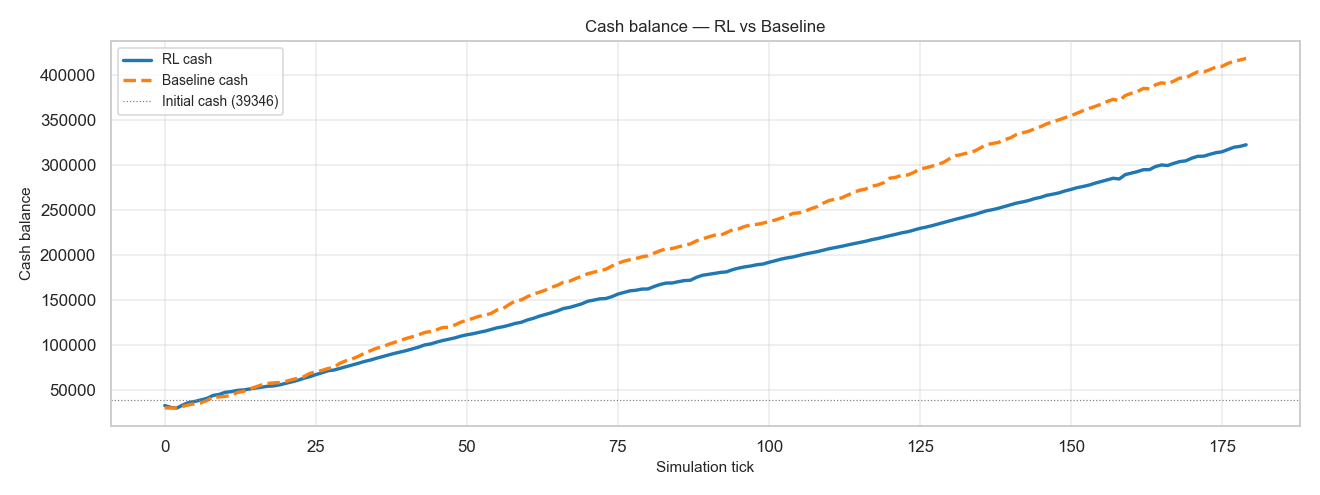

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, s in [('RL', step_rl), ('Baseline', step_bl)]:
    ax.plot(s['tick'], s['cash'], color=POLICY_COLOR[name],
            ls=POLICY_LS[name], lw=2.2, label=f'{name} cash')
ax.axhline(initial_cash_recorded, color='gray', lw=0.8, ls=':',
           label=f'Initial cash ({initial_cash_recorded:.0f})')
ax.set_xlabel('Simulation tick')
ax.set_ylabel('Cash balance')
ax.set_title('Cash balance — RL vs Baseline')
ax.legend(loc='best')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

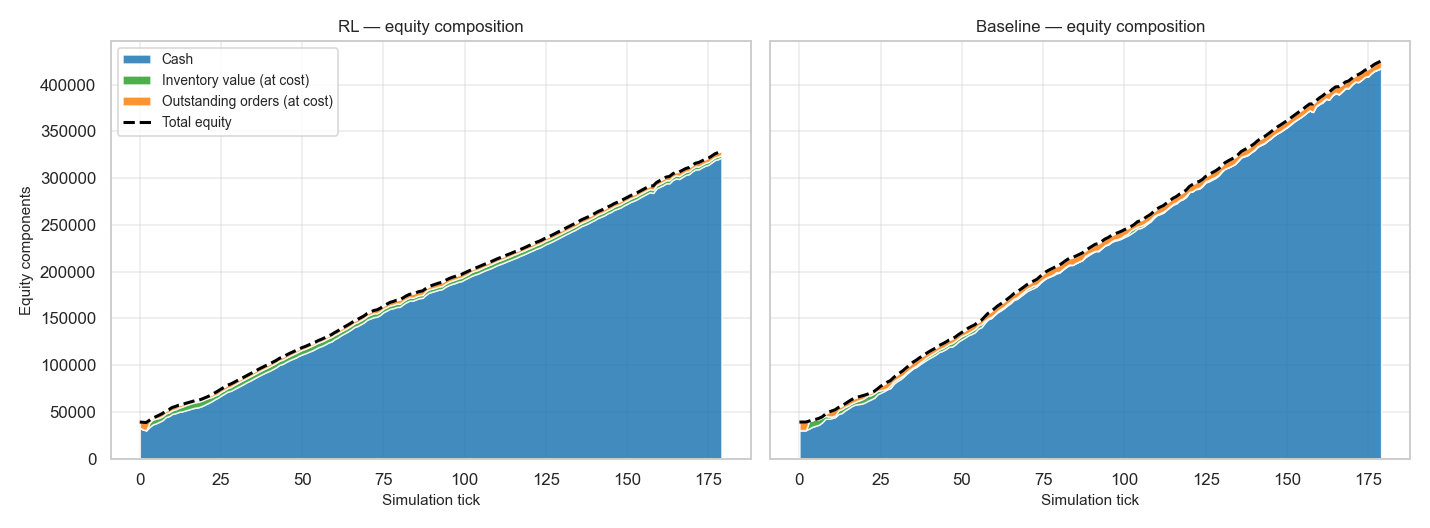

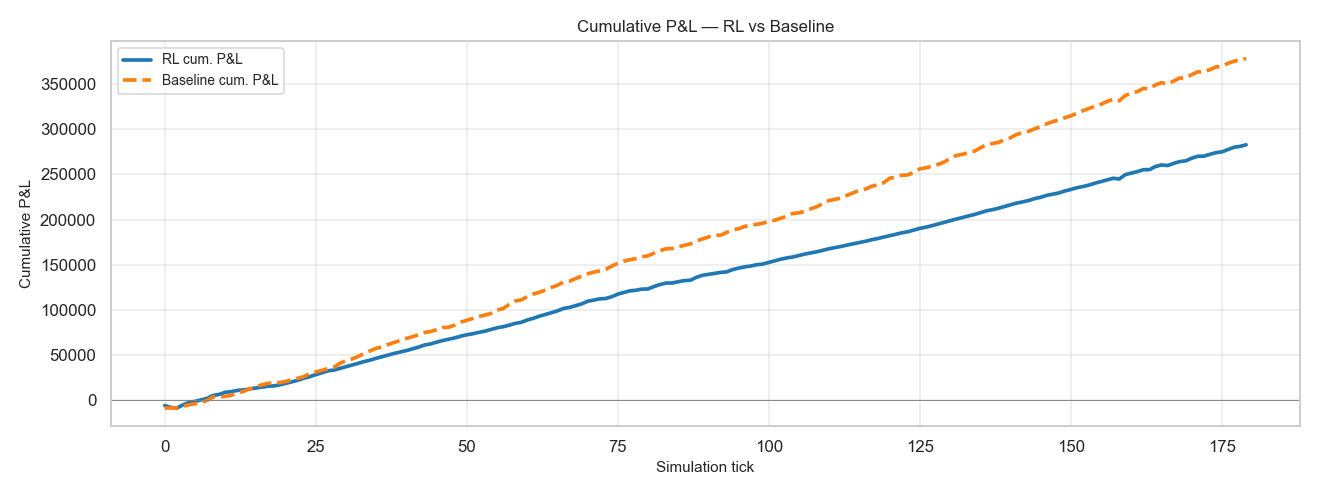

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (name, s) in zip(axes, [('RL', step_rl), ('Baseline', step_bl)]):
    ax.stackplot(
        s['tick'], s['cash'], s['inventory_value'], s['outstanding_value'],
        labels=['Cash', 'Inventory value (at cost)', 'Outstanding orders (at cost)'],
        colors=['#1f77b4', '#2ca02c', '#ff7f0e'], alpha=0.85,
    )
    ax.plot(s['tick'], s['equity'], color='black', lw=2.0, ls='--', label='Total equity')
    ax.set_title(f'{name} — equity composition')
    ax.set_xlabel('Simulation tick')
    ax.grid(True, alpha=0.4)
axes[0].set_ylabel('Equity components')
axes[0].legend(loc='upper left')
fig.tight_layout()
plt.show()

# Cumulative P&L overlay.
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, s in [('RL', step_rl), ('Baseline', step_bl)]:
    ax.plot(s['tick'], s['cumulative_profit'], color=POLICY_COLOR[name],
            ls=POLICY_LS[name], lw=2.4, label=f'{name} cum. P&L')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('Simulation tick')
ax.set_ylabel('Cumulative P&L')
ax.set_title('Cumulative P&L — RL vs Baseline')
ax.legend(loc='best')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

## 8. Per-step P&L decomposition

Revenue (positive bar) vs order + holding cost (negative bars), with step P&L overlaid as a line. Rendered side-by-side so the bar heights are visually comparable.

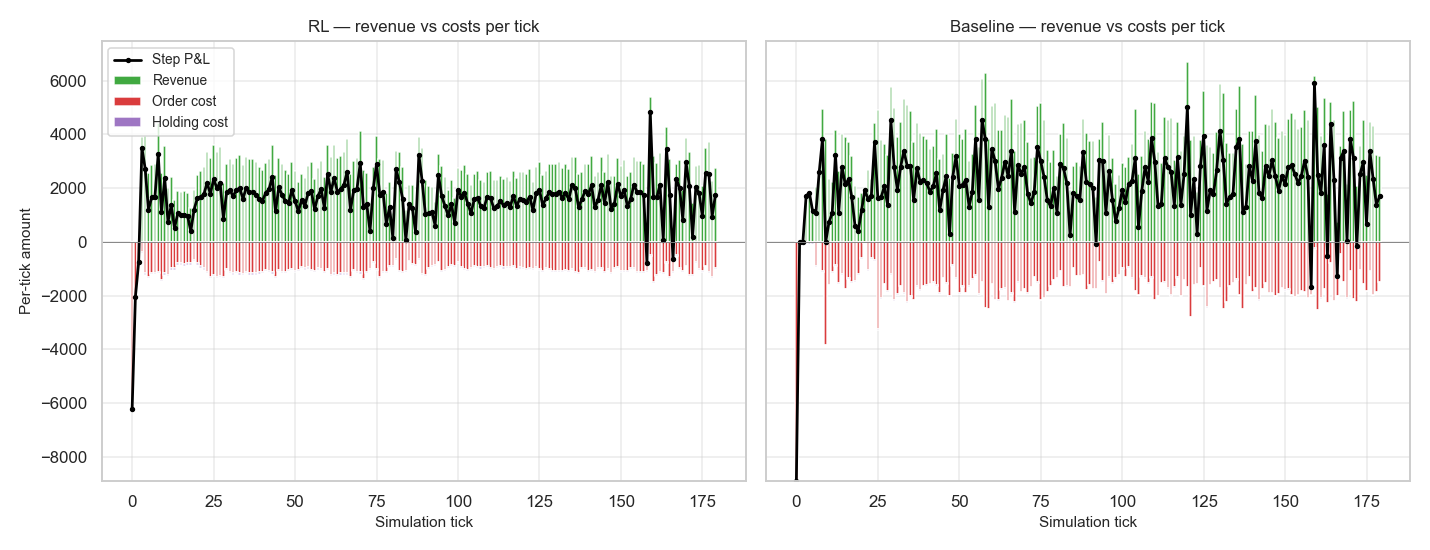

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (name, s) in zip(axes, [('RL', step_rl), ('Baseline', step_bl)]):
    ax.bar(s['tick'], s['revenue'], color='#2ca02c', alpha=0.9, label='Revenue')
    order_cost = s['total_cost'] - s['holding_cost']
    ax.bar(s['tick'], -order_cost, color='#d62728', alpha=0.9, label='Order cost')
    ax.bar(s['tick'], -s['holding_cost'], bottom=-order_cost,
           color='#9467bd', alpha=0.9, label='Holding cost')
    ax.plot(s['tick'], s['step_profit'], color='black', lw=1.8,
            marker='o', ms=2.5, label='Step P&L')
    ax.axhline(0, color='gray', lw=0.6)
    ax.set_title(f'{name} — revenue vs costs per tick')
    ax.set_xlabel('Simulation tick')
    ax.grid(True, alpha=0.4)
axes[0].set_ylabel('Per-tick amount')
axes[0].legend(loc='upper left')
fig.tight_layout()
plt.show()

## 9. Store-level decision signals

Active SKU count, on-promo count, order qty (sum across SKUs), outstanding orders, and median active-SKU price / MSRP — every signal overlaid for both policies. Note: the RL action vector ignores activate / deactivate / promotion fields (see `decode_action`), so the RL line for those will be flat.

Active count and on-promo count are computed at decision time (after `store.decide` settled them for the tick).

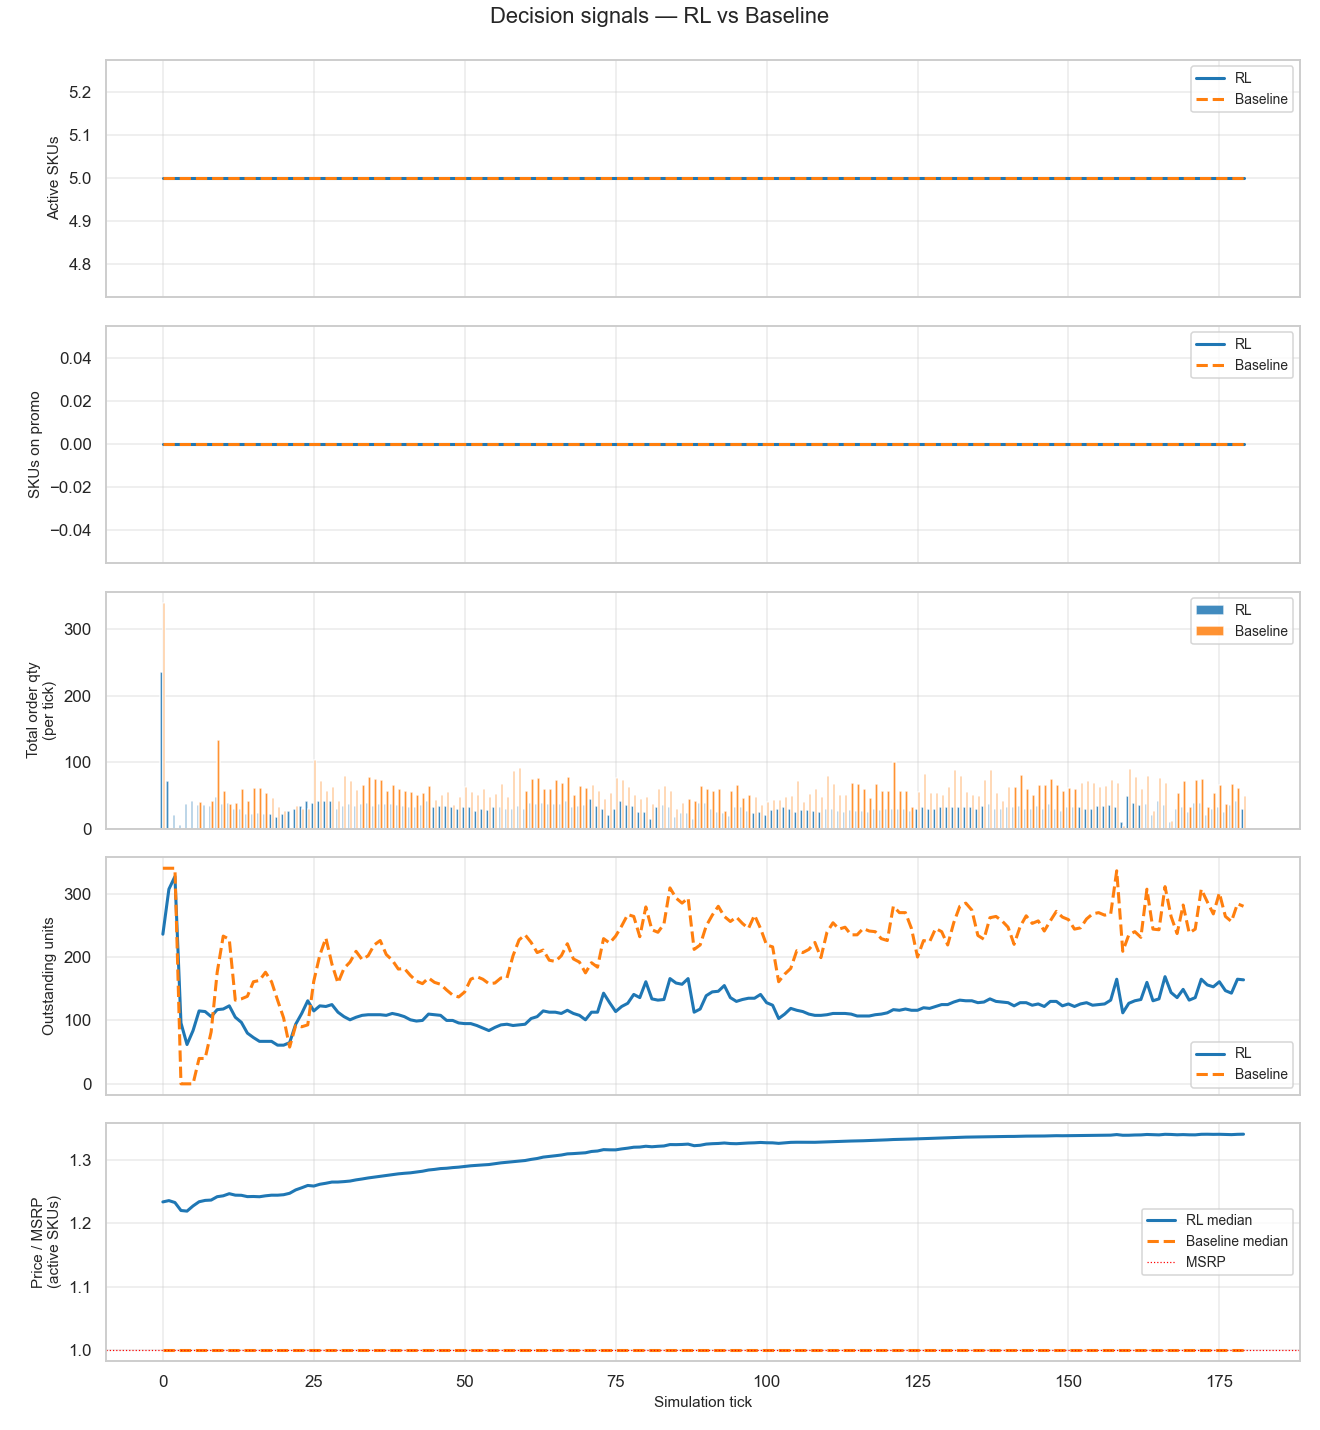

In [11]:
def store_signals(t):
    by_tick = t.groupby(['tick'], as_index=False).agg(
        active_count=('active', 'sum'),
        on_promo=('on_promo', 'sum'),
        order_qty=('order_qty', 'sum'),
        outstanding=('outstanding', 'sum'),
    )
    active_only = t[t['active']].copy()
    active_only['price_ratio'] = active_only['price'] / active_only['base_price']
    pr = active_only.groupby('tick', as_index=False).agg(
        median_price_ratio=('price_ratio', 'median'),
        mean_price_ratio=('price_ratio', 'mean'),
    )
    return by_tick.merge(pr, on='tick', how='left')

sig_rl = store_signals(traj_rl)
sig_bl = store_signals(traj_bl)

fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)

# Active SKU count.
for name, sig in [('RL', sig_rl), ('Baseline', sig_bl)]:
    axes[0].plot(sig['tick'], sig['active_count'], color=POLICY_COLOR[name],
                 ls=POLICY_LS[name], lw=2.0, label=name)
axes[0].set_ylabel('Active SKUs')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.4)

# On promo count.
for name, sig in [('RL', sig_rl), ('Baseline', sig_bl)]:
    axes[1].plot(sig['tick'], sig['on_promo'], color=POLICY_COLOR[name],
                 ls=POLICY_LS[name], lw=2.0, label=name)
axes[1].set_ylabel('SKUs on promo')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.4)

# Order qty (total per tick).
width = 0.4
axes[2].bar(sig_rl['tick'] - width / 2, sig_rl['order_qty'], width=width,
            color=POLICY_COLOR['RL'], alpha=0.85, label='RL')
axes[2].bar(sig_bl['tick'] + width / 2, sig_bl['order_qty'], width=width,
            color=POLICY_COLOR['Baseline'], alpha=0.85, label='Baseline')
axes[2].set_ylabel('Total order qty\n(per tick)')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.4)

# Outstanding orders.
for name, sig in [('RL', sig_rl), ('Baseline', sig_bl)]:
    axes[3].plot(sig['tick'], sig['outstanding'], color=POLICY_COLOR[name],
                 ls=POLICY_LS[name], lw=2.0, label=name)
axes[3].set_ylabel('Outstanding units')
axes[3].legend(loc='best')
axes[3].grid(True, alpha=0.4)

# Median active-SKU price / MSRP.
for name, sig in [('RL', sig_rl), ('Baseline', sig_bl)]:
    axes[4].plot(sig['tick'], sig['median_price_ratio'], color=POLICY_COLOR[name],
                 ls=POLICY_LS[name], lw=2.0, label=f'{name} median')
axes[4].axhline(1.0, color='red', lw=0.8, ls=':', label='MSRP')
axes[4].set_ylabel('Price / MSRP\n(active SKUs)')
axes[4].set_xlabel('Simulation tick')
axes[4].legend(loc='best')
axes[4].grid(True, alpha=0.4)

fig.suptitle('Decision signals — RL vs Baseline', y=0.995)
fig.tight_layout()
plt.show()

## 10. Store total inventory vs capacity

On-hand inventory summed across all active SKUs vs the store's hard capacity ceiling. Outstanding orders are excluded (those don't take floor space until they arrive).

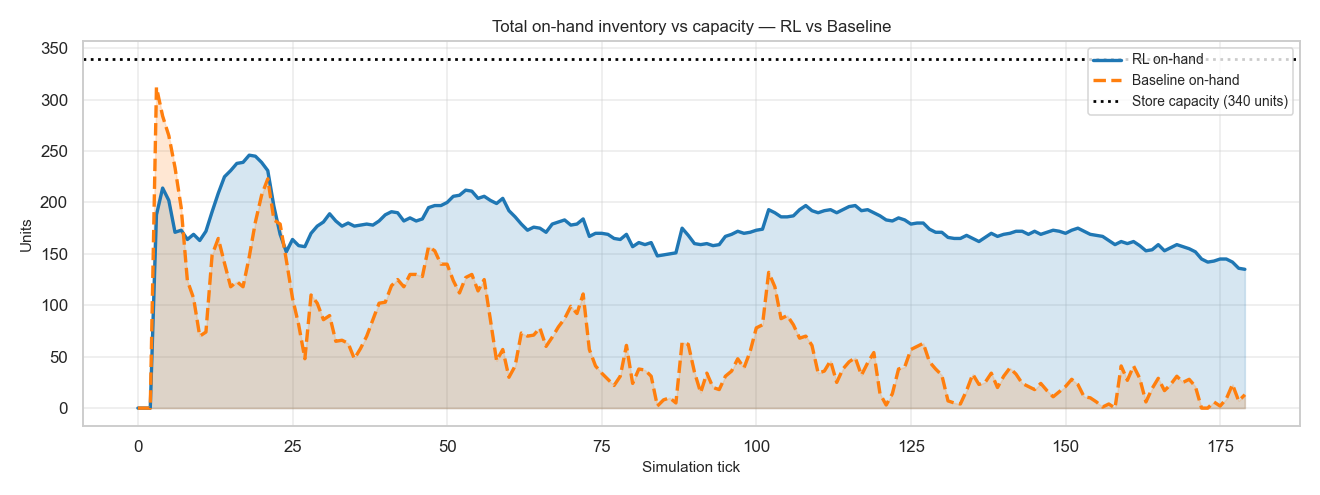

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for name, s in [('RL', step_rl), ('Baseline', step_bl)]:
    ax.fill_between(s['tick'], 0, s['total_inventory'],
                    color=POLICY_COLOR[name], alpha=0.18)
    ax.plot(s['tick'], s['total_inventory'], color=POLICY_COLOR[name],
            ls=POLICY_LS[name], lw=2.2, label=f'{name} on-hand')
ax.axhline(store_capacity, color='black', lw=1.8, ls=':',
           label=f'Store capacity ({store_capacity:.0f} units)')
ax.set_xlabel('Simulation tick')
ax.set_ylabel('Units')
ax.set_title('Total on-hand inventory vs capacity — RL vs Baseline')
ax.legend(loc='best')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

## 11. Per-product cards

One card per SKU in `spec.active_subset`, sorted by combined demand. Each card stacks five panels with the RL and Baseline traces overlaid:

1. Inventory + outstanding + order quantity (orders shown as side-by-side bars)
2. Demand vs sales — world-level inputs (market supply, lifecycle stage, disruption windows) are CRN-paired and bit-identical, but realised demand still depends on the policy's chosen price via the elasticity term, so the two demand curves should be close but not equal. Sales divergence is the policy's inventory decisions cascading to stockouts.
3. Price vs base price vs unit cost
4. Cumulative profit
5. State strip — active (green) / on-promo (purple), one row per policy

In [13]:
demand_rank = (
    traj.groupby('product_id')['demand'].sum().sort_values(ascending=False)
)
ordered_pids = demand_rank.index.tolist()
name_by_pid = {w.product_id: w.name for w in spec.scenario.catalog}
category_by_pid = {w.product_id: w.category for w in spec.scenario.catalog}
print('SKUs sorted by total demand across both runs:')
for pid in ordered_pids:
    print(f'  {pid:>10}  {name_by_pid.get(pid, "?"):30s}  total_demand={demand_rank[pid]:.0f}')

SKUs sorted by total demand across both runs:
       P0012  Classic Leather Loafer          total_demand=8710
       P0006  Oxford Button Down Shirt        total_demand=7279
       P0007  Slim Fit Chino Pant             total_demand=4135
       P0009  Brushed Flannel Overshirt       total_demand=3435
       P0004  Soft Knit Mock Neck Sweater     total_demand=2672


In [14]:
def render_product_card(pid):
    g_rl = traj_rl[traj_rl['product_id'] == pid].sort_values('tick').reset_index(drop=True)
    g_bl = traj_bl[traj_bl['product_id'] == pid].sort_values('tick').reset_index(drop=True)
    if g_rl.empty or g_bl.empty:
        print(f'No rows for product {pid}')
        return

    g_rl = g_rl.assign(cum_profit=g_rl['profit'].cumsum())
    g_bl = g_bl.assign(cum_profit=g_bl['profit'].cumsum())
    name = name_by_pid.get(pid, '?')
    cat = category_by_pid.get(pid, '?')

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 13), sharex=True,
        gridspec_kw={'height_ratios': [3, 3, 3, 2.4, 1.2]},
    )
    ax_inv, ax_ds, ax_pr, ax_pnl, ax_state = axes

    # 1. Inventory + outstanding + order qty.
    width = 0.4
    for g, name_p, offset in [(g_rl, 'RL', -width / 2), (g_bl, 'Baseline', width / 2)]:
        ax_inv.plot(g['tick'], g['inventory'], color=POLICY_COLOR[name_p],
                    ls=POLICY_LS[name_p], lw=2.0, label=f'{name_p} inventory')
        ax_inv.plot(g['tick'], g['outstanding'], color=POLICY_COLOR[name_p],
                    ls=POLICY_LS[name_p], lw=1.4, alpha=0.55,
                    label=f'{name_p} outstanding')
        ax_inv.bar(g['tick'] + offset, g['order_qty'], width=width,
                   color=POLICY_COLOR[name_p], alpha=0.55,
                   label=f'{name_p} order qty')
    ax_inv.set_ylabel('Units')
    ax_inv.legend(loc='upper right', ncol=2, fontsize=8)
    ax_inv.grid(True, alpha=0.4)

    # 2. Demand vs sales (CRN at world level; demand drifts slightly with price).
    for g, name_p in [(g_rl, 'RL'), (g_bl, 'Baseline')]:
        ax_ds.plot(g['tick'], g['demand'], color=POLICY_COLOR[name_p],
                   ls=POLICY_LS[name_p], lw=1.4, alpha=0.6,
                   label=f'{name_p} demand')
        ax_ds.plot(g['tick'], g['sales'], color=POLICY_COLOR[name_p],
                   ls=POLICY_LS[name_p], lw=2.2,
                   label=f'{name_p} sales')
    ax_ds.fill_between(g_rl['tick'], g_rl['sales'], g_rl['demand'],
                       where=(g_rl['demand'] > g_rl['sales']),
                       color=POLICY_COLOR['RL'], alpha=0.18, label='RL unmet')
    ax_ds.fill_between(g_bl['tick'], g_bl['sales'], g_bl['demand'],
                       where=(g_bl['demand'] > g_bl['sales']),
                       color=POLICY_COLOR['Baseline'], alpha=0.18, label='Baseline unmet')
    ax_ds.set_ylabel('Units')
    ax_ds.legend(loc='upper right', ncol=3, fontsize=8)
    ax_ds.grid(True, alpha=0.4)

    # 3. Price (RL / Baseline) vs base price vs unit cost.
    for g, name_p in [(g_rl, 'RL'), (g_bl, 'Baseline')]:
        ax_pr.plot(g['tick'], g['price'], color=POLICY_COLOR[name_p],
                   ls=POLICY_LS[name_p], lw=2.0, label=f'{name_p} price')
    ax_pr.plot(g_rl['tick'], g_rl['base_price'], color='gray', lw=1.4, ls=':',
               label='Base price')
    ax_pr.plot(g_rl['tick'], g_rl['unit_cost'], color='red', lw=1.4, ls=':',
               label='Unit cost')
    ax_pr.set_ylabel('Price')
    ax_pr.legend(loc='upper right', ncol=2, fontsize=8)
    ax_pr.grid(True, alpha=0.4)

    # 4. Cumulative profit.
    for g, name_p in [(g_rl, 'RL'), (g_bl, 'Baseline')]:
        ax_pnl.plot(g['tick'], g['cum_profit'], color=POLICY_COLOR[name_p],
                    ls=POLICY_LS[name_p], lw=2.2, label=f'{name_p} cum. profit')
    ax_pnl.axhline(0, color='gray', lw=0.6)
    ax_pnl.set_ylabel('Cum. profit')
    ax_pnl.legend(loc='best', fontsize=8)
    ax_pnl.grid(True, alpha=0.4)

    # 5. State strip — two rows (RL top, Baseline bottom).
    for row_idx, (g, name_p) in enumerate([(g_rl, 'RL'), (g_bl, 'Baseline')]):
        y0 = 1 - row_idx
        ax_state.fill_between(g['tick'], y0, y0 + 0.45,
                              where=g['active'].astype(bool), step='post',
                              color='#2ca02c', alpha=0.55)
        ax_state.fill_between(g['tick'], y0 + 0.45, y0 + 0.9,
                              where=g['on_promo'].astype(bool), step='post',
                              color='#9467bd', alpha=0.7)
    ax_state.set_yticks([0.5, 1.5])
    ax_state.set_yticklabels(['Baseline', 'RL'])
    ax_state.set_ylim(-0.1, 2.1)
    ax_state.legend(handles=[
        Patch(color='#2ca02c', alpha=0.55, label='Active'),
        Patch(color='#9467bd', alpha=0.7, label='On promo'),
    ], loc='upper right', ncol=2, fontsize=8)
    ax_state.grid(True, alpha=0.3, axis='x')

    ax_state.set_xlabel('Simulation tick')
    rl_prof = g_rl['profit'].sum()
    bl_prof = g_bl['profit'].sum()
    rl_dem = int(g_rl['demand'].sum())
    bl_dem = int(g_bl['demand'].sum())
    rl_sal = int(g_rl['sales'].sum())
    bl_sal = int(g_bl['sales'].sum())
    fig.suptitle(
        f'{pid}  —  {name}  ({cat})\n'
        f'RL: profit={rl_prof:.0f}  demand={rl_dem}  sales={rl_sal}   |   '
        f'Baseline: profit={bl_prof:.0f}  demand={bl_dem}  sales={bl_sal}   |   '
        f'uplift={rl_prof - bl_prof:+.0f}',
        y=0.995,
    )
    fig.tight_layout()
    plt.show()

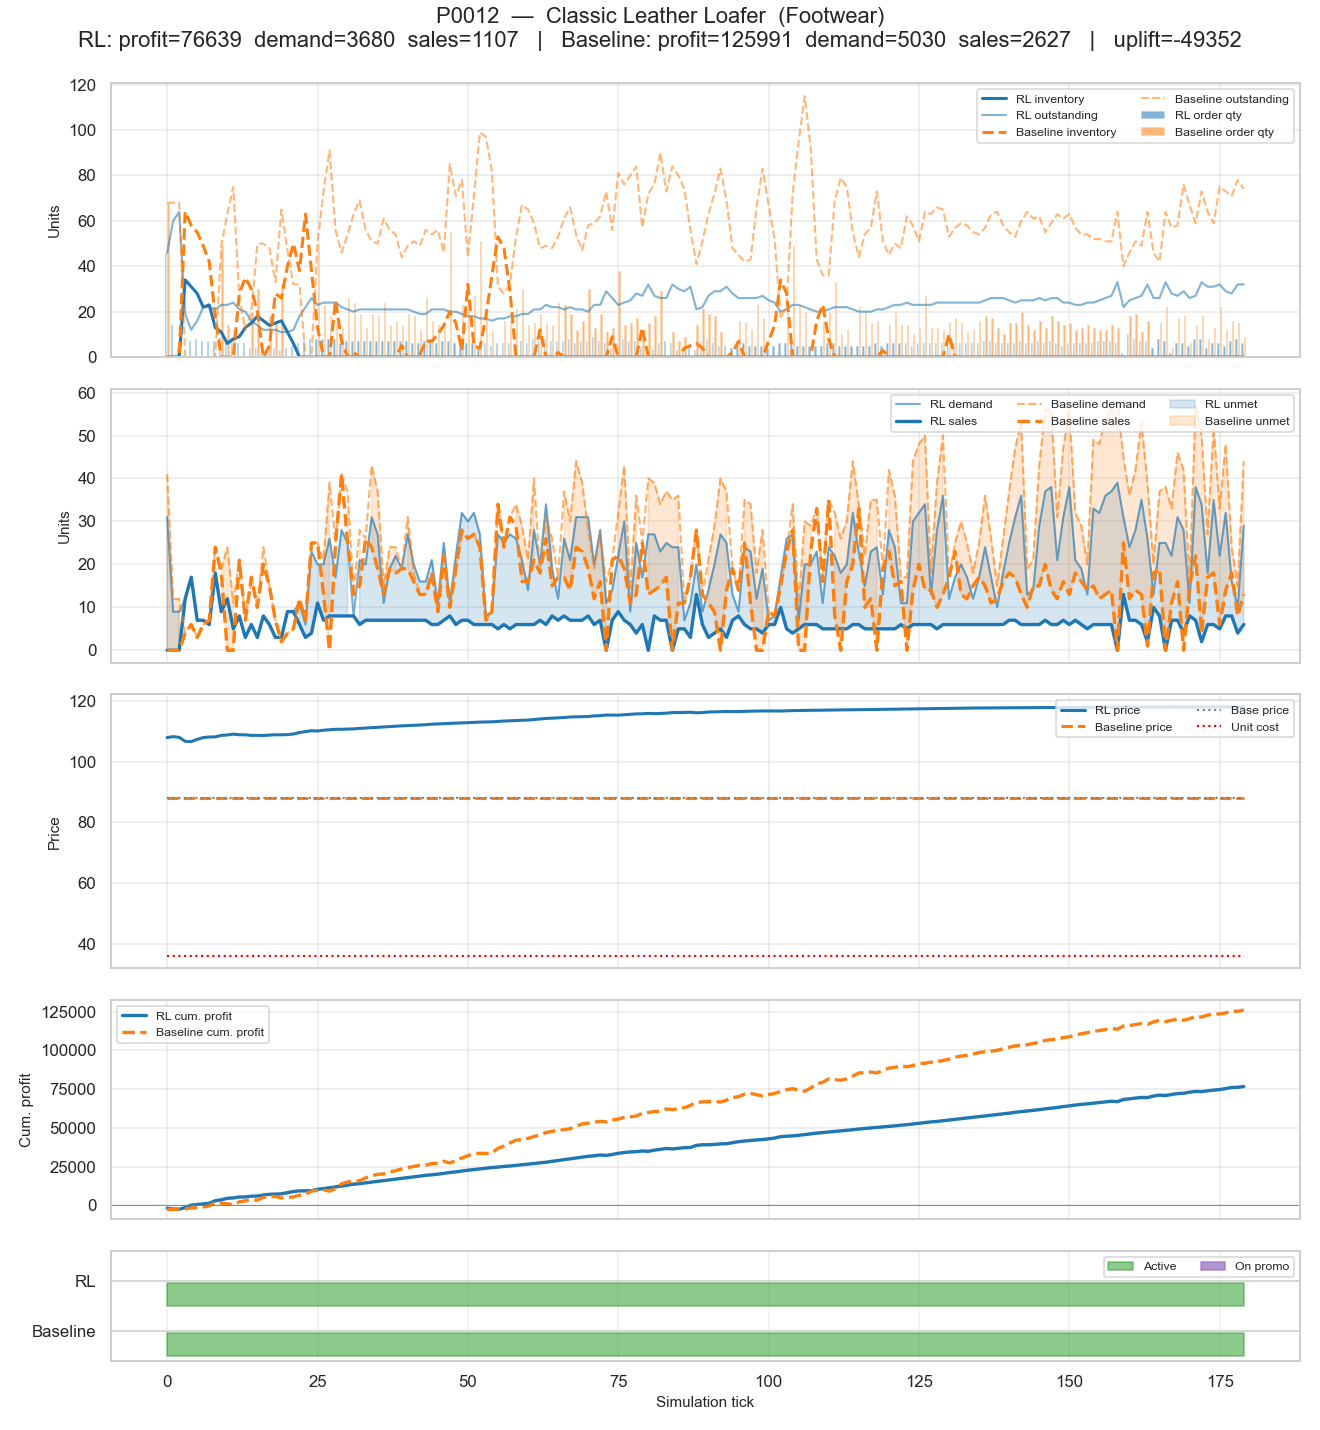

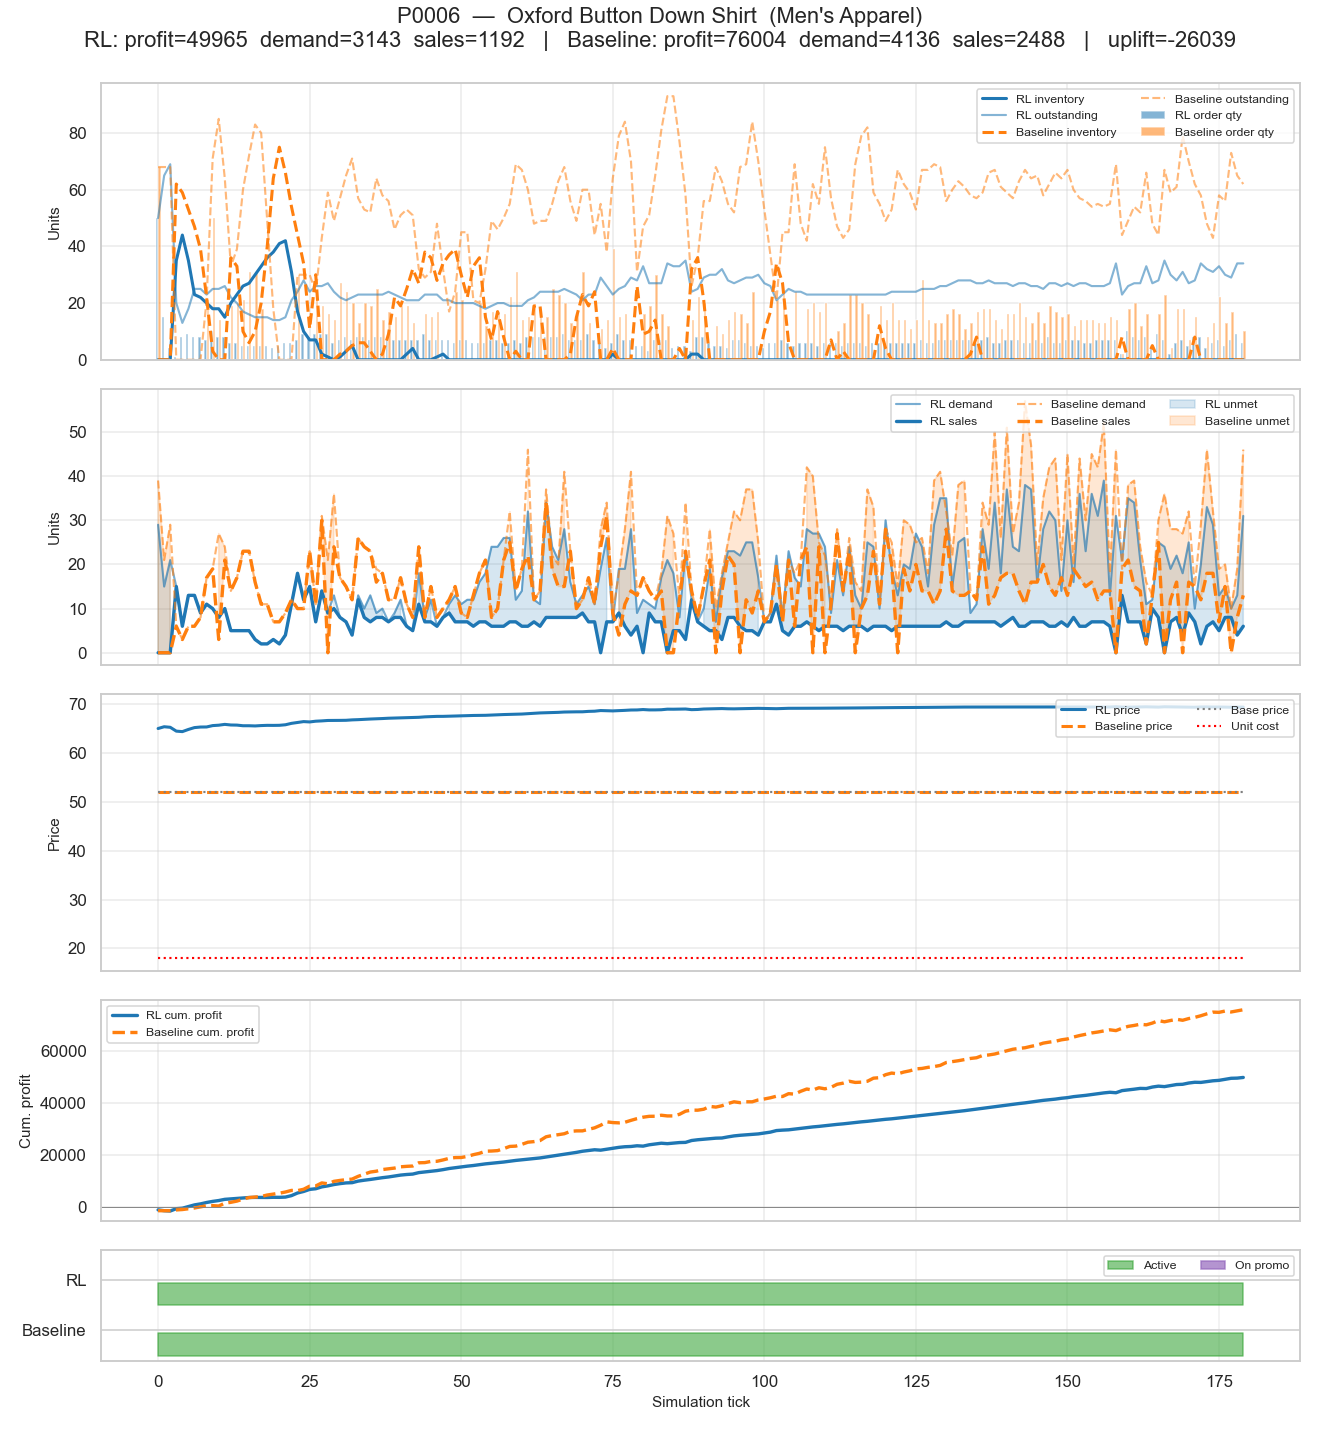

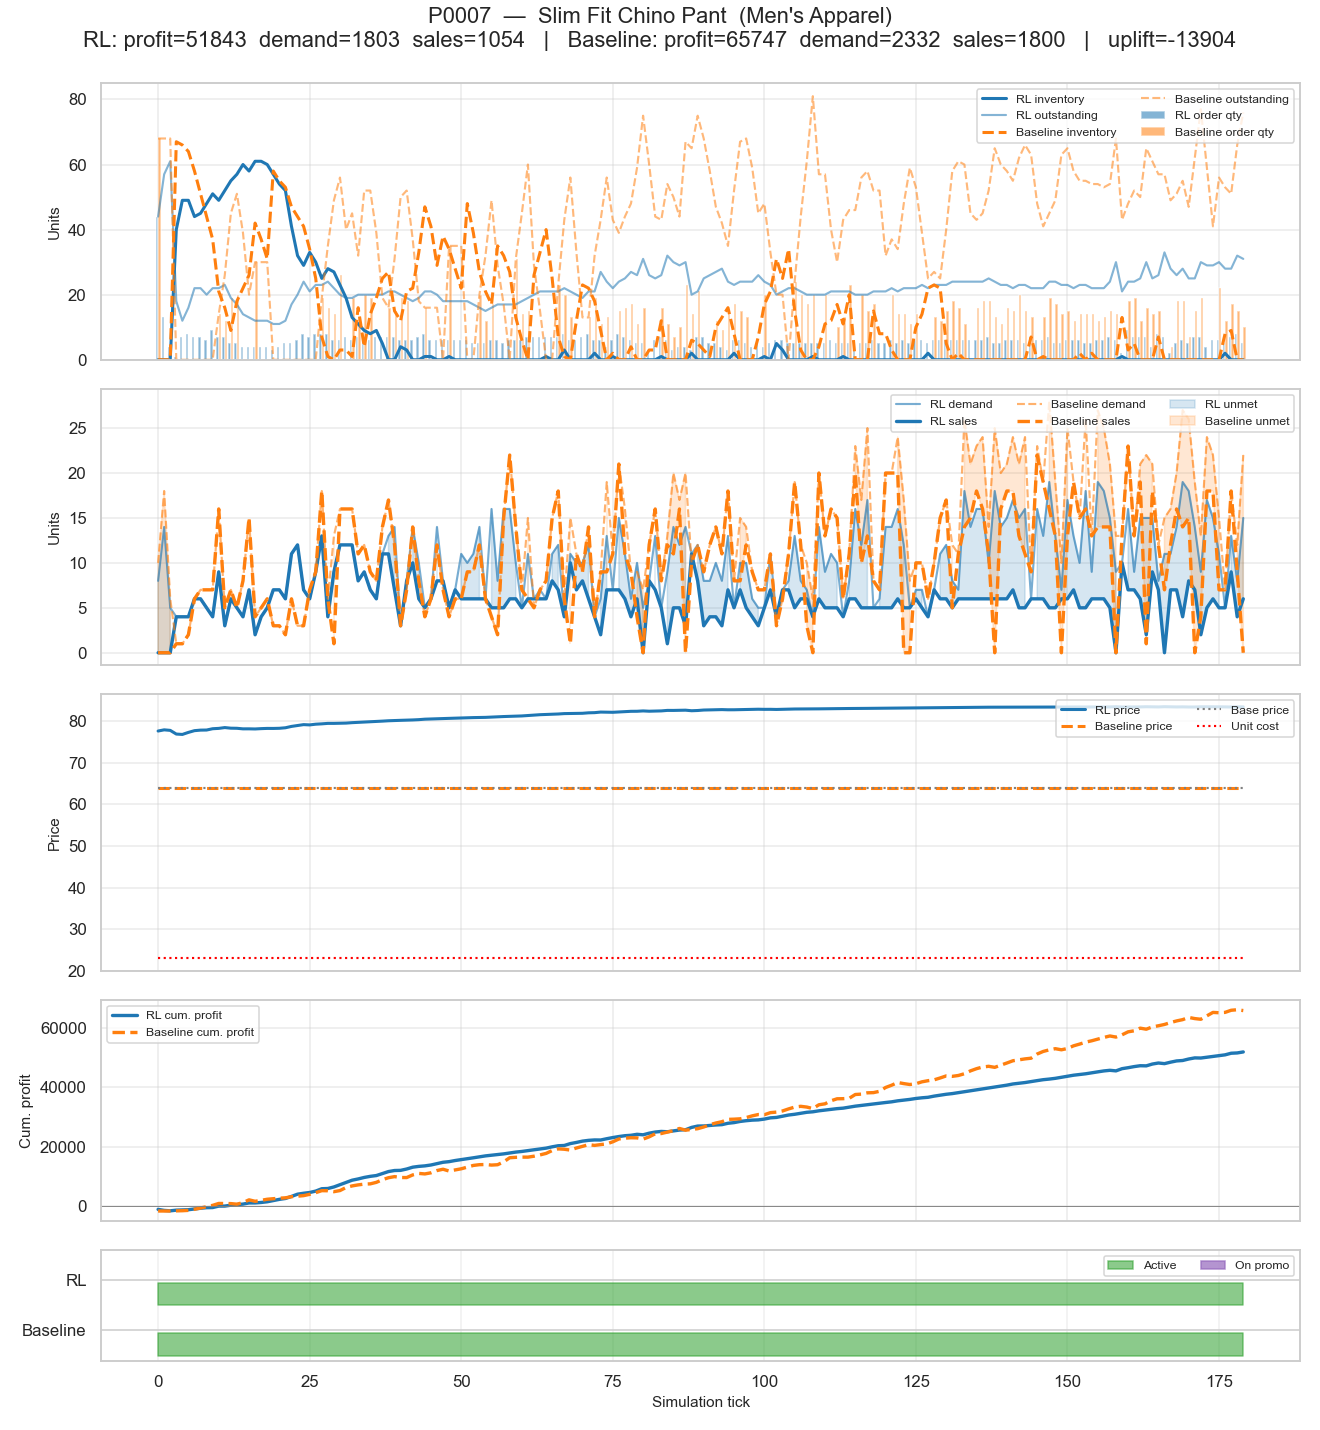

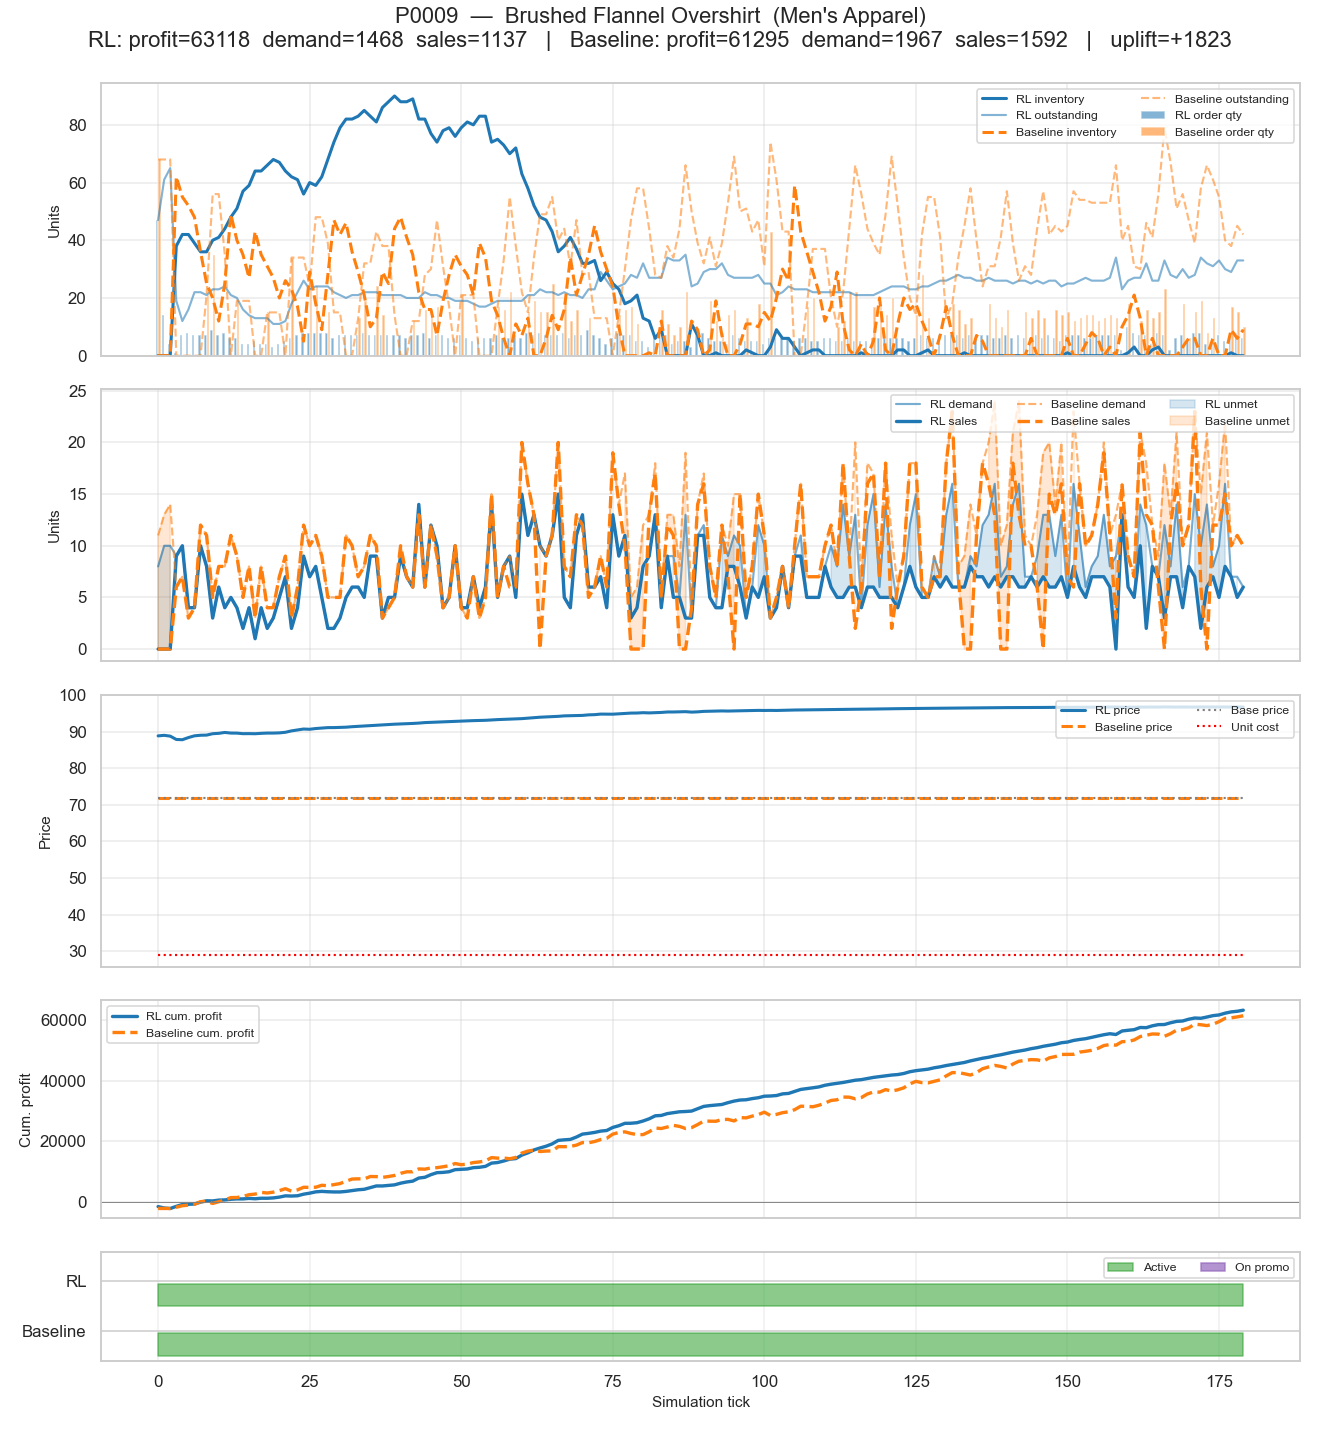

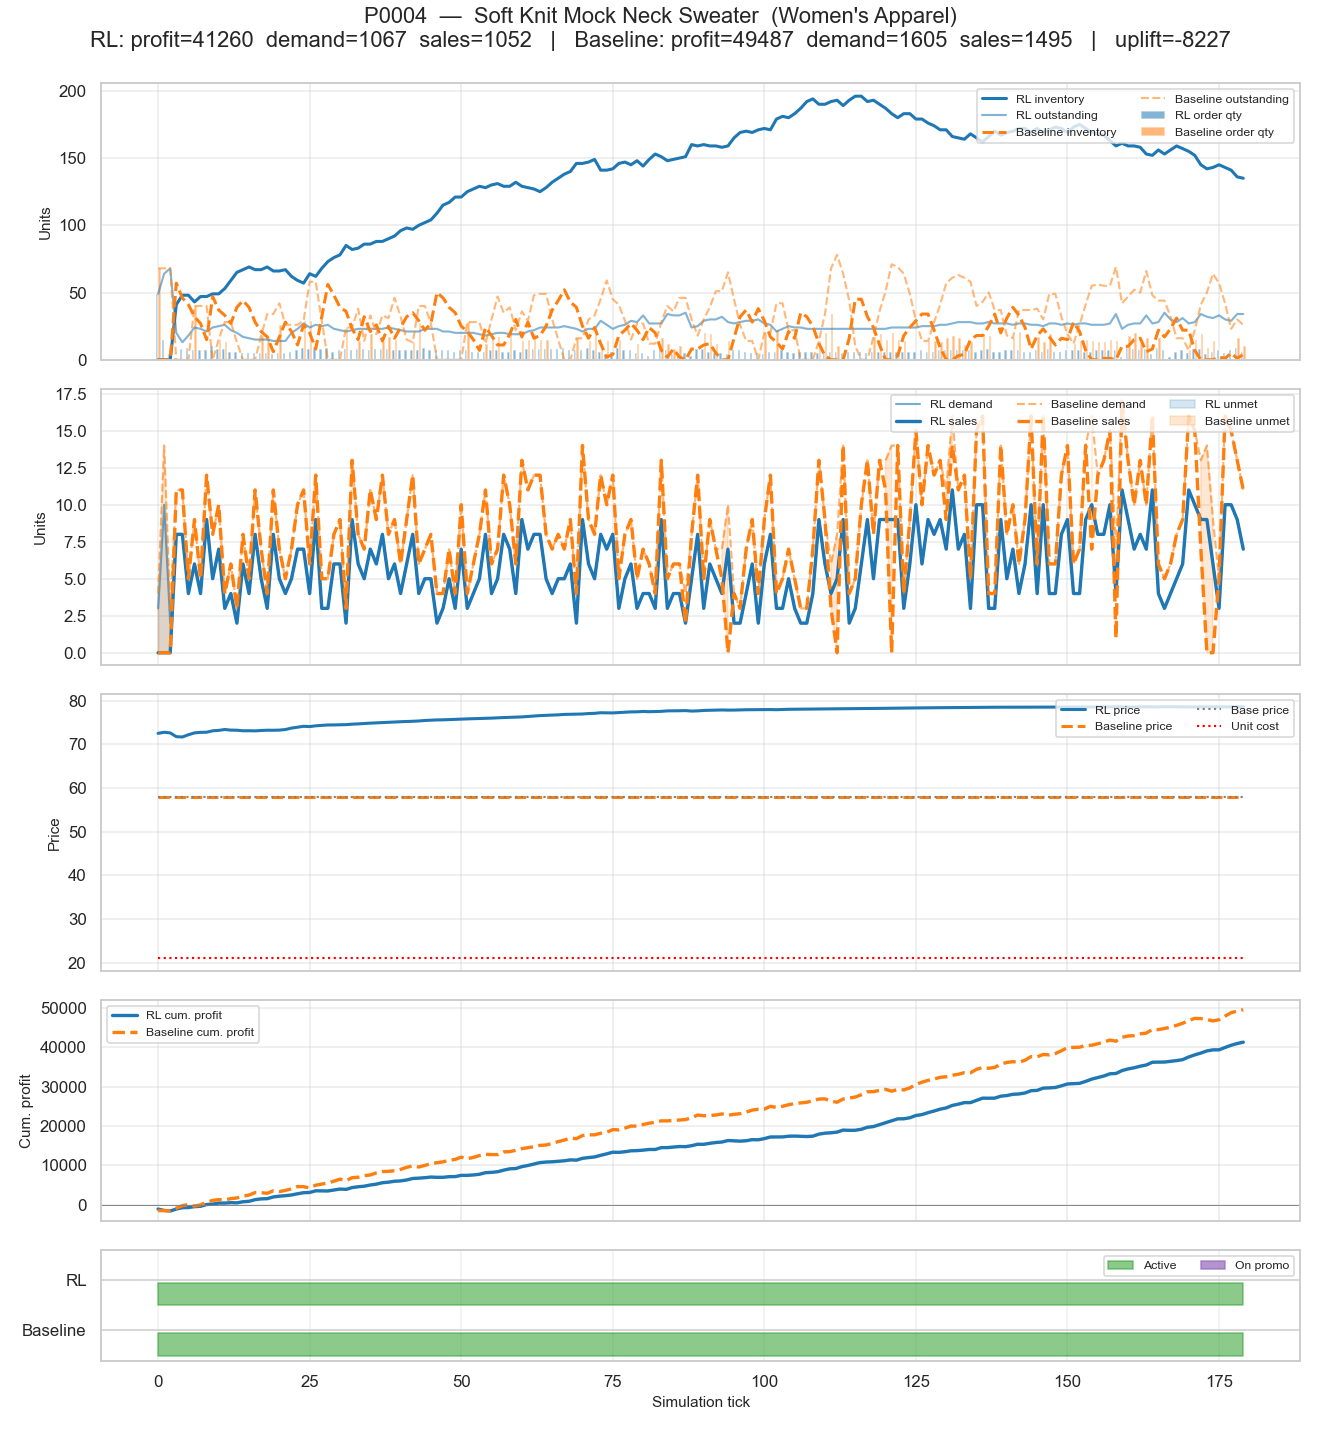

In [15]:
# Render every active SKU, busiest first. Truncate ordered_pids if you only
# want the top few (e.g. `ordered_pids[:3]`).
for pid in ordered_pids:
    render_product_card(pid)

## 12. Final-step snapshot

Per-SKU totals at the end of the episode. Sorted by `Δ profit` so the SKUs where the policy diverges most show up first.

In [16]:
totals = (
    traj.groupby(['product_id', 'policy'], as_index=False).agg(
        total_demand=('demand', 'sum'),
        total_sales=('sales', 'sum'),
        total_revenue=('revenue', 'sum'),
        total_profit=('profit', 'sum'),
        active_ticks=('active', 'sum'),
        promo_ticks=('on_promo', 'sum'),
    )
)
totals['fill_rate'] = totals['total_sales'] / totals['total_demand'].replace(0, np.nan)
wide = totals.pivot(index='product_id', columns='policy',
                    values=['total_demand', 'total_sales', 'total_profit',
                            'fill_rate', 'promo_ticks'])
wide.columns = [f'{m}_{p}' for m, p in wide.columns]
wide['delta_profit'] = wide['total_profit_RL'] - wide['total_profit_Baseline']
wide['name'] = wide.index.map(name_by_pid)
wide = wide.sort_values('delta_profit', ascending=False).reset_index()
wide[[
    'product_id', 'name',
    'total_demand_RL', 'total_demand_Baseline',
    'total_sales_RL', 'total_sales_Baseline',
    'fill_rate_RL', 'fill_rate_Baseline',
    'total_profit_RL', 'total_profit_Baseline', 'delta_profit',
    'promo_ticks_RL', 'promo_ticks_Baseline',
]].round(3)

,product_id,name,total_demand_RL,total_demand_Baseline,total_sales_RL,total_sales_Baseline,fill_rate_RL,fill_rate_Baseline,total_profit_RL,total_profit_Baseline,delta_profit,promo_ticks_RL,promo_ticks_Baseline
0,P0009,Brushed Flannel Overshirt,1468.0,1967.0,1137.0,1592.0,0.775,0.809,63117.563,61294.58,1822.983,0.0,0.0
1,P0004,Soft Knit Mock Neck Sweater,1067.0,1605.0,1052.0,1495.0,0.986,0.931,41259.720,49486.77,-8227.050,0.0,0.0
2,P0007,Slim Fit Chino Pant,1803.0,2332.0,1054.0,1800.0,0.585,0.772,51843.352,65747.24,-13903.888,0.0,0.0
3,P0006,Oxford Button Down Shirt,3143.0,4136.0,1192.0,2488.0,0.379,0.602,49965.149,76003.80,-26038.651,0.0,0.0
4,P0012,Classic Leather Loafer,3680.0,5030.0,1107.0,2627.0,0.301,0.522,76639.142,125990.72,-49351.578,0.0,0.0
